In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [4]:
df = pd.read_csv("../data/processed/cleaned_telco.csv")

In [5]:
monthly = (
    df.groupby("Tenure_Months")["Monthly_Charges"]
      .mean()
      .reset_index()
)

monthly.head()

,Tenure_Months,Monthly_Charges
0,0,41.418182
1,1,50.485808
2,2,57.206303
3,3,58.015000
4,4,57.432670


In [6]:
monthly["Date"] = pd.date_range(
    start="2020-01-01",
    periods=len(monthly),
    freq="MS"
)

monthly.set_index("Date", inplace=True)

monthly.head()

,Tenure_Months,Monthly_Charges
Date,,
2020-01-01,0,41.418182
2020-02-01,1,50.485808
2020-03-01,2,57.206303
2020-04-01,3,58.015000
2020-05-01,4,57.432670


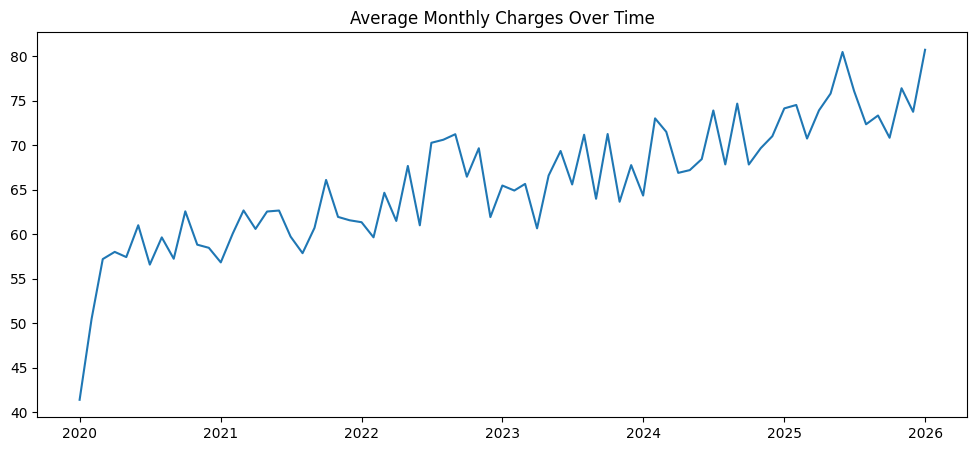

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly.index,
    monthly["Monthly_Charges"]
)

plt.title("Average Monthly Charges Over Time")

plt.show()

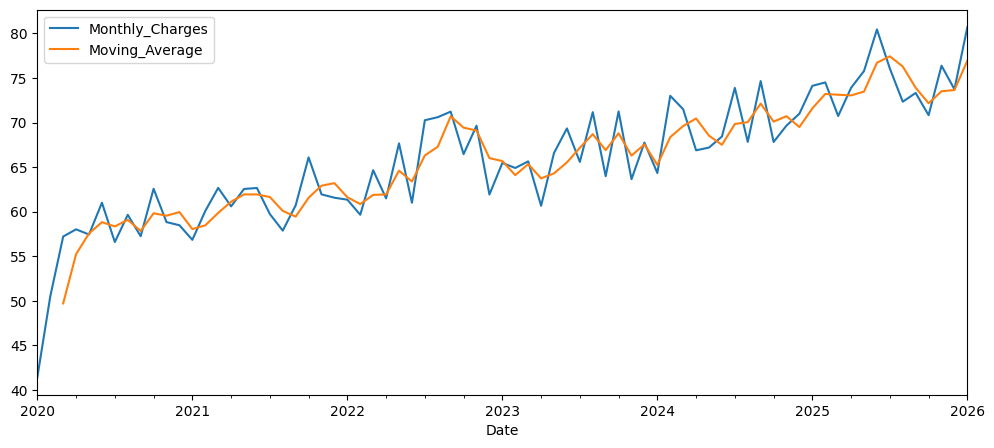

In [8]:
monthly["Moving_Average"] = (
    monthly["Monthly_Charges"]
    .rolling(3)
    .mean()
)

monthly[["Monthly_Charges","Moving_Average"]].plot(figsize=(12,5))
plt.show()

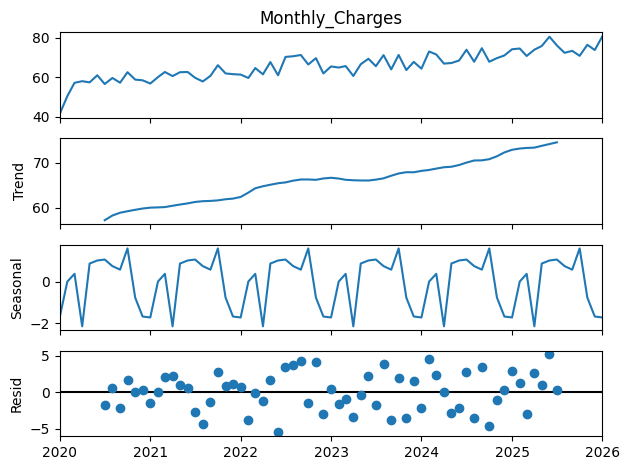

In [9]:
decomposition = seasonal_decompose(
    monthly["Monthly_Charges"],
    model="additive",
    period=12
)

decomposition.plot()

plt.show()

In [10]:
result = adfuller(monthly["Monthly_Charges"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.2920082786397437
p-value: 0.9266285974818688


c:\Users\purua\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


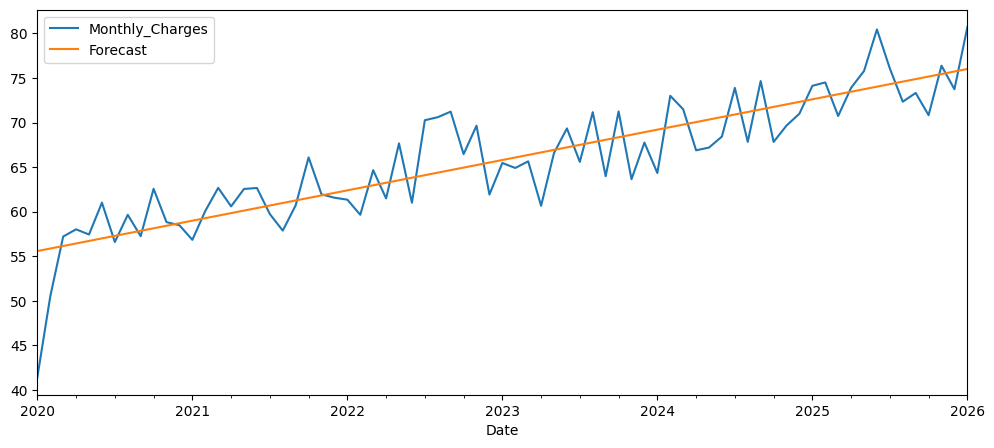

In [11]:
model = ExponentialSmoothing(
    monthly["Monthly_Charges"],
    trend="add"
)

fit = model.fit()

monthly["Forecast"] = fit.fittedvalues

monthly[["Monthly_Charges","Forecast"]].plot(figsize=(12,5))
plt.show()

In [12]:
model = ARIMA(
    monthly["Monthly_Charges"],
    order=(1,1,1)
)

fit = model.fit()

forecast = fit.forecast(12)

print(forecast)

2026-02-01    77.057986
2026-03-01    79.774897
2026-04-01    77.745797
2026-05-01    79.261212
2026-06-01    78.129438
2026-07-01    78.974693
2026-08-01    78.343422
2026-09-01    78.814881
2026-10-01    78.462776
2026-11-01    78.725742
2026-12-01    78.529348
2027-01-01    78.676023
Freq: MS, Name: predicted_mean, dtype: float64


c:\Users\purua\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\purua\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\purua\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [13]:
pred = fit.predict()

mae = mean_absolute_error(
    monthly["Monthly_Charges"][1:],
    pred[1:]
)

rmse = np.sqrt(
    mean_squared_error(
        monthly["Monthly_Charges"][1:],
        pred[1:]
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

MAE : 3.091295347013864
RMSE: 3.760117797446891
